# _NLP with Deep Learning_

In [1]:
import pandas as pd
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input, Dropout

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from textblob import TextBlob

In [2]:
df=pd.read_csv('yelp.csv')

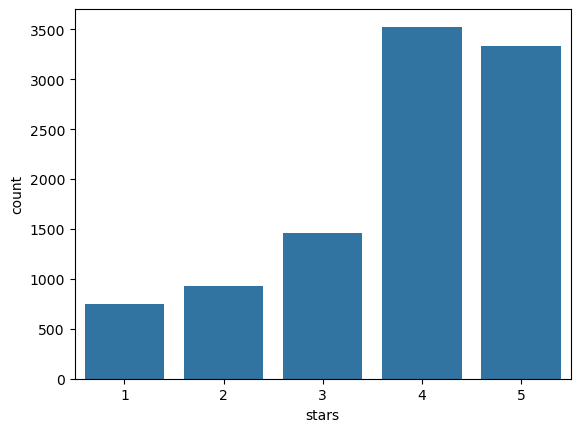

In [3]:
sns.countplot(x=df['stars']);

In [4]:
df['text']=df['text'].str.lower() # kucuk harfe cevir
df['text']=df['text'].str.replace('[^\w\s]','', regex=True) # noktolama isaretlerini kaldirir
df['text']=df['text'].str.replace('\d+','', regex=True) # rakamlari kaldirir
df['text']=df['text'].str.replace('\n','', regex=True) # satir sonlarini kaldirir
df['text']=df['text'].str.replace('\r','', regex=True) # enter lari kaldirir

In [5]:
ybw=df[(df.stars==1)| (df.stars==5)]

In [6]:
ybw=ybw.reset_index(drop=True)

In [7]:
ybw

,business_id,date,review_id,stars,text,type,user_id,cool,useful,funny
0,9yKzy9PApeiPPOUJEtnvkg,2011-01-26,fWKvX83p0-ka4JS3dc6E5A,5,my wife took me here on my birthday for breakf...,review,rLtl8ZkDX5vH5nAx9C3q5Q,2,5,0
1,ZRJwVLyzEJq1VAihDhYiow,2011-07-27,IjZ33sJrzXqU-0X6U8NwyA,5,i have no idea why some people give bad review...,review,0a2KyEL0d3Yb1V6aivbIuQ,0,0,0
2,_1QQZuf4zZOyFCvXc0o6Vg,2010-05-27,G-WvGaISbqqaMHlNnByodA,5,rosie dakota and i love chaparral dog park its...,review,uZetl9T0NcROGOyFfughhg,1,2,0
3,6ozycU1RpktNG2-1BroVtw,2012-01-05,1uJFq2r5QfJG_6ExMRCaGw,5,general manager scott petello is a good egg no...,review,vYmM4KTsC8ZfQBg-j5MWkw,0,0,0
4,zp713qNhx8d9KCJJnrw1xA,2010-02-12,riFQ3vxNpP4rWLk_CSri2A,5,drop what youre doing and drive here after i a...,review,wFweIWhv2fREZV_dYkz_1g,7,7,4
...,...,...,...,...,...,...,...,...,...,...
4081,R8VwdLyvsp9iybNqRvm94g,2011-10-03,pcEeHdAJPoFNF23es0kKWg,5,yes i do rock the hipster joints i dig this p...,review,b92Y3tyWTQQZ5FLifex62Q,1,1,1
4082,WJ5mq4EiWYAA4Vif0xDfdg,2011-12-05,EuHX-39FR7tyyG1ElvN1Jw,5,only stars a few notes the folks that rated t...,review,hTau-iNZFwoNsPCaiIUTEA,1,1,0
4083,f96lWMIAUhYIYy9gOktivQ,2009-03-10,YF17z7HWlMj6aezZc-pVEw,5,im not normally one to jump at reviewing a cha...,review,W_QXYA7A0IhMrvbckz7eVg,2,3,2
4084,L3BSpFvxcNf3T_teitgt6A,2012-03-19,0nxb1gIGFgk3WbC5zwhKZg,5,lets seewhat is there not to like about surpri...,review,OzOZv-Knlw3oz9K5Kh5S6A,1,2,1


In [8]:
x=ybw['text']
y=ybw[['stars']]

In [9]:
d={1:0,5:1}

In [10]:
y['stars']=y['stars'].map(d)

C:\Users\13tua\AppData\Local\Temp\ipykernel_7056\361118301.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  y['stars']=y['stars'].map(d)


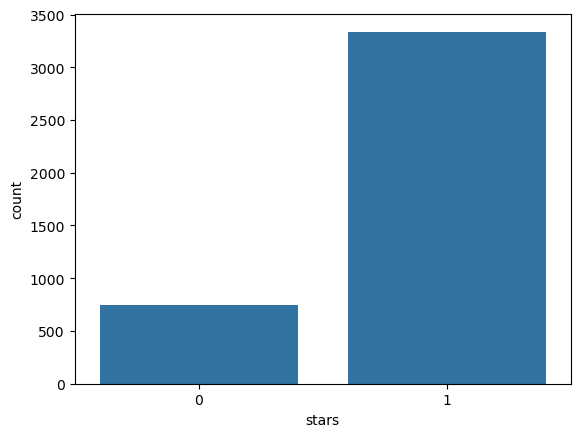

In [11]:
sns.countplot(x=y['stars']);

In [12]:
def ekkok(text):
    words=TextBlob(text).words
    return [word.lemmatize() for word in words]

In [13]:
vect=CountVectorizer(stop_words='english', analyzer=ekkok,ngram_range=(1,2))

In [14]:
x_vect = vect.fit_transform(x).toarray() 

C:\Users\13tua\anaconda3\Lib\site-packages\sklearn\feature_extraction\text.py:533: UserWarning: The parameter 'ngram_range' will not be used since 'analyzer' is callable'
  warnings.warn(
C:\Users\13tua\anaconda3\Lib\site-packages\sklearn\feature_extraction\text.py:539: UserWarning: The parameter 'stop_words' will not be used since 'analyzer' != 'word'
  warnings.warn(


In [15]:
tf=pd.DataFrame(vect.fit_transform(x).toarray(), columns=vect.get_feature_names_out())

In [16]:
tf # bag of words, word embedings BERT, ALBERTA, mistrial

,a,aa,aaa,aaaamazingthey,aaammmazzingits,aaron,aathis,ab,aback,abandoned,...,zuchinni,zumba,zupa,zupas,zuzu,zuzus,zwiebelkräuter,éclairs,école,ém
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,6,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4081,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4082,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4083,7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4084,11,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [17]:
x_train, x_test, y_train, y_test = train_test_split(x_vect, y, test_size=0.2, random_state=42)

In [18]:
model=Sequential([
    Dense(256, activation='relu'), # hayal urunu Black box nature of DL
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid') # classification son layer sigmoid eger 1-0 ise softmax 2 den fazla secenek icin
])
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

In [19]:
model.fit(x_train, y_train, batch_size=32, validation_data=(x_test, y_test), verbose=2, epochs=15)

Epoch 1/15
103/103 - 5s - 50ms/step - accuracy: 0.8736 - loss: 0.3272 - val_accuracy: 0.9181 - val_loss: 0.2146
Epoch 2/15
103/103 - 3s - 33ms/step - accuracy: 0.9801 - loss: 0.0608 - val_accuracy: 0.9242 - val_loss: 0.2393
Epoch 3/15
103/103 - 3s - 31ms/step - accuracy: 0.9979 - loss: 0.0084 - val_accuracy: 0.9108 - val_loss: 0.5585
Epoch 4/15
103/103 - 3s - 30ms/step - accuracy: 0.9902 - loss: 0.0435 - val_accuracy: 0.9095 - val_loss: 0.6272
Epoch 5/15
103/103 - 3s - 31ms/step - accuracy: 0.9951 - loss: 0.0162 - val_accuracy: 0.9108 - val_loss: 0.3659
Epoch 6/15
103/103 - 3s - 31ms/step - accuracy: 1.0000 - loss: 0.0012 - val_accuracy: 0.9205 - val_loss: 0.5451
Epoch 7/15
103/103 - 3s - 32ms/step - accuracy: 1.0000 - loss: 2.0925e-04 - val_accuracy: 0.9205 - val_loss: 0.6211
Epoch 8/15
103/103 - 4s - 35ms/step - accuracy: 1.0000 - loss: 1.0332e-04 - val_accuracy: 0.9205 - val_loss: 0.6662
Epoch 9/15
103/103 - 3s - 34ms/step - accuracy: 1.0000 - loss: 6.4112e-05 - val_accuracy: 0.9205

In [20]:
model.evaluate(x_test, y_test) 

26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9181 - loss: 0.8889 


[0.8888546228408813, 0.9180929064750671]

In [21]:
neg = df[df['stars'] == 1]['text'].iloc[0] 

In [23]:
pos=df[df['stars']==5]['text'].iloc[0]

In [24]:
text1=vect.transform([pos]).toarray()

In [25]:
text2=vect.transform([neg]).toarray()

In [27]:
p1 = model.predict(text1)[0][0].astype('int8')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step


In [28]:
p1

np.int8(1)

In [29]:
p2 = model.predict(text2)[0][0].astype('int8')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step


In [30]:
p2

np.int8(0)

In [31]:
label=['Negative','Positive']

In [32]:
label[p1]

'Positive'

In [33]:
label[p2]

'Negative'

In [35]:
model.save('sentiment.keras')

In [36]:
from keras.models import load_model

In [37]:
model2=load_model('sentiment.keras')

In [38]:
p3 = model.predict(text1)[0][0].astype('int8')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step


In [39]:
label[p3]

'Positive'

# _NLP with Neat Text_

In [40]:
import pandas as pd

In [41]:
df=pd.read_csv('yelp.csv')

In [43]:
#pip install neattext

In [44]:
df['text']

0       My wife took me here on my birthday for breakf...
1       I have no idea why some people give bad review...
2       love the gyro plate. Rice is so good and I als...
3       Rosie, Dakota, and I LOVE Chaparral Dog Park!!...
4       General Manager Scott Petello is a good egg!!!...
                              ...                        
9995    First visit...Had lunch here today - used my G...
9996    Should be called house of deliciousness!\n\nI ...
9997    I recently visited Olive and Ivy for business ...
9998    My nephew just moved to Scottsdale recently so...
9999    4-5 locations.. all 4.5 star average.. I think...
Name: text, Length: 10000, dtype: object

In [46]:
s=' '.join(df['text'])

In [47]:
from collections import Counter  

In [48]:
Counter(s.split())

Counter({'the': 54809,
         'and': 42015,
         'a': 34951,
         'I': 34293,
         'to': 29621,
         'of': 20615,
         'was': 19627,
         'is': 16809,
         'for': 14327,
         'in': 13724,
         'it': 11738,
         'The': 11418,
         'that': 10847,
         'with': 10414,
         'but': 9319,
         'my': 9062,
         'you': 8782,
         'on': 8681,
         'have': 8526,
         'this': 7593,
         'are': 6910,
         'had': 6716,
         'they': 6713,
         'not': 6368,
         'at': 6144,
         'were': 5895,
         'we': 5493,
         'be': 5337,
         'so': 5266,
         'as': 5170,
         'place': 5133,
         'like': 4578,
         'just': 4056,
         'food': 4004,
         'good': 3972,
         'very': 3837,
         'or': 3642,
         'out': 3630,
         'get': 3595,
         'me': 3509,
         'all': 3473,
         'their': 3433,
         'there': 3348,
         'from': 3345,
         'one': 32

In [49]:
import neattext.functions as nfx  

In [50]:
s2 = nfx.remove_stopwords(s) 

In [51]:
Counter(s2.split())  

Counter({'place': 5133,
         'like': 4578,
         'food': 4004,
         'good': 3972,
         'great': 3120,
         '-': 2859,
         'time': 2432,
         'little': 2142,
         "I'm": 2083,
         "I've": 1998,
         'service': 1843,
         'got': 1740,
         'love': 1696,
         'pretty': 1686,
         'nice': 1576,
         'ordered': 1552,
         'it.': 1497,
         'think': 1438,
         'best': 1435,
         'try': 1368,
         'know': 1362,
         'going': 1356,
         'people': 1338,
         'went': 1277,
         'order': 1219,
         'came': 1208,
         'good.': 1206,
         'want': 1174,
         'restaurant': 1171,
         'come': 1140,
         'staff': 1105,
         'chicken': 1099,
         'way': 1091,
         'better': 1086,
         'menu': 1065,
         '&': 1022,
         'right': 1000,
         'definitely': 984,
         'bit': 984,
         'find': 983,
         'bar': 975,
         'eat': 939,
         "can't"

In [53]:
data = Counter(s2.split()).most_common(20) # en cok tekrar eden 20 kelime

In [54]:
data = dict(data)

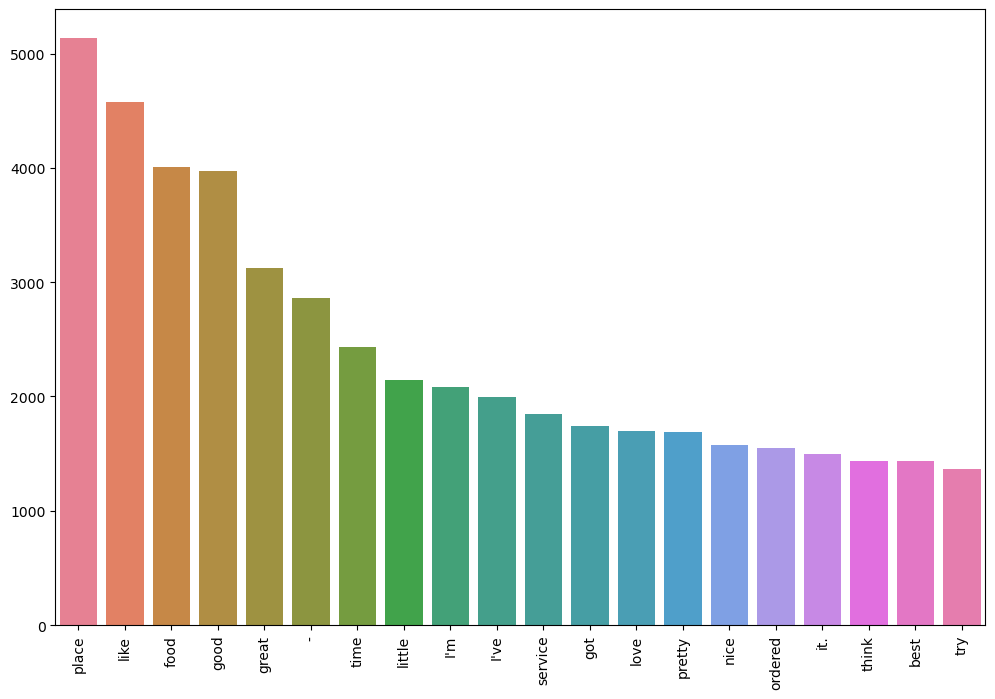

In [55]:
plt.figure(figsize=(12,8))  
sns.barplot(x=list(data.keys()), y=list(data.values()), hue=list(data.keys()))  
plt.xticks(rotation=90);  

In [56]:
iyi = df[df['stars'] == 5]

In [57]:
iyicumle = ' '.join(iyi['text'])

In [58]:
ic = nfx.remove_stopwords(iyicumle) 

In [59]:
Counter(ic.split())

Counter({'place': 1485,
         'great': 1272,
         'like': 1155,
         'food': 1094,
         'good': 1015,
         '-': 849,
         'love': 790,
         "I've": 759,
         'time': 743,
         'best': 716,
         'little': 548,
         "I'm": 543,
         'service': 506,
         'it.': 445,
         'got': 439,
         'know': 419,
         'nice': 408,
         'staff': 404,
         'going': 392,
         'try': 390,
         'favorite': 380,
         "can't": 345,
         'Great': 337,
         'want': 333,
         'went': 331,
         'restaurant': 329,
         'people': 326,
         'come': 325,
         'fresh': 324,
         'think': 324,
         'recommend': 318,
         'right': 316,
         '&': 312,
         'new': 307,
         'friendly': 307,
         'eat': 306,
         'find': 305,
         'menu': 303,
         'wait': 302,
         'ordered': 302,
         'pretty': 299,
         'definitely': 299,
         'order': 297,
         'chic

In [60]:
data = Counter(ic.split()).most_common(20)

In [61]:
data = dict(data)

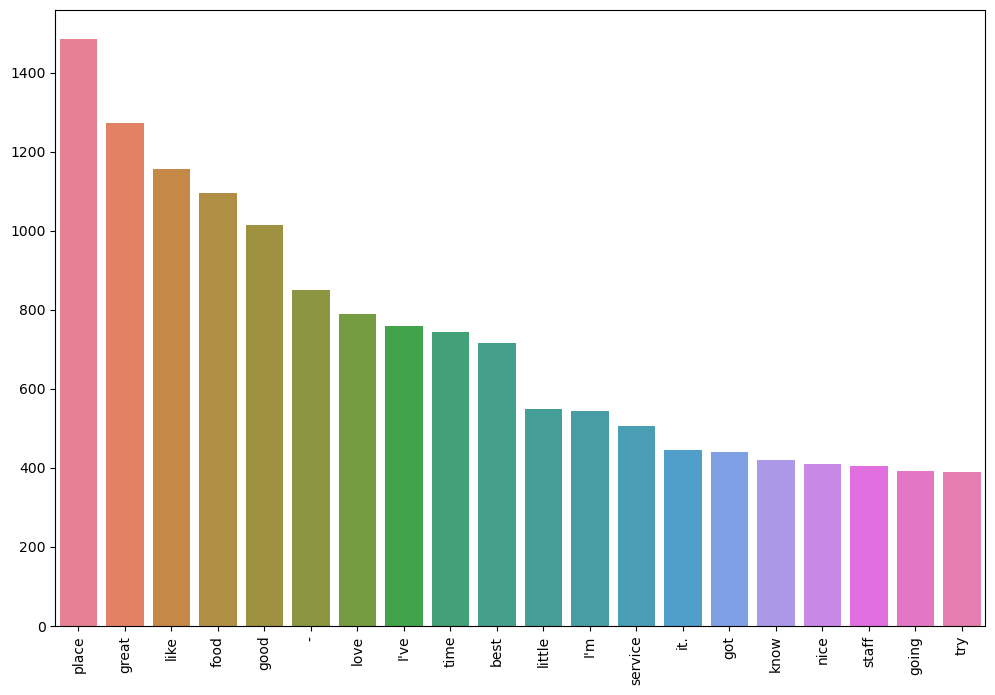

In [62]:
plt.figure(figsize=(12,8))  
sns.barplot(x=list(data.keys()), y=list(data.values()), hue=list(data.keys()))  
plt.xticks(rotation=90);  